In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
import obonet
import networkx as nx
import math

# RNA PBPA

In [2]:
def PBPA(RNA_i, RNA_j, di_sim, rna_di):
    diseaseSet_i = rna_di[RNA_i] > 0
    diseaseSet_j = rna_di[RNA_j] > 0
    diseaseSim_ij = di_sim[diseaseSet_i][:, diseaseSet_j]
    ijshape = diseaseSim_ij.shape
    if ijshape[0] == 0 or ijshape[1] == 0:
        return 0
    return (sum(np.max(diseaseSim_ij, axis=0)) + sum(np.max(diseaseSim_ij, axis=1))) / (ijshape[0] + ijshape[1])

In [3]:
def getRNASiNet(RNAlen, diSiNet, rna_di):
    RNASiNet = np.zeros((RNAlen, RNAlen))
    for i in range(RNAlen):
        for j in range(i + 1, RNAlen):
            RNASiNet[i, j] = RNASiNet[j, i] = PBPA(i, j, diSiNet, rna_di)
    return RNASiNet

# wang的疾病语义相似性

In [5]:
# url = 'https://raw.githubusercontent.com/DiseaseOntology/HumanDiseaseOntology/main/src/ontology/doid.obo'
# HDO_Net = obonet.read_obo(url)

In [4]:
local_file_path = "C:/Users/49696/0 jupyter/0/raw.githubusercontent.com_DiseaseOntology_HumanDiseaseOntology_main_src_ontology_doid.obo"
HDO_Net = obonet.read_obo(local_file_path)

In [5]:
def get_SV(disease, w):
    S = HDO_Net.subgraph(nx.descendants(HDO_Net, disease) | {disease})
    SV = dict()
    shortest_paths = nx.shortest_path(S, source=disease)
    for x in shortest_paths:
        SV[x] = math.pow(w, (len(shortest_paths[x]) - 1))
    return SV

In [6]:
def get_similarity(d1, d2, w):
    SV1 = get_SV(d1, w)
    SV2 = get_SV(d2, w)
    intersection_value= 0
    for disease in (set(SV1.keys()) & set(SV2.keys())):
        intersection_value = intersection_value + SV1[disease]
        intersection_value = intersection_value + SV2[disease]
    return intersection_value / (sum(SV1.values()) + sum(SV2.values()))

In [7]:
def getDiSiNet(dilen, diseases, w):
    diSiNet = np.zeros((dilen, dilen))
    for d1 in range(dilen):
        if diseases[d1] in HDO_Net.nodes:
            for d2 in range(d1 + 1, dilen):
                if diseases[d2] in HDO_Net.nodes:
                    diSiNet[d1, d2] = diSiNet[d2, d1] = get_similarity(diseases[d1], diseases[d2], w)
    return diSiNet

# 5 folds

In [8]:
from sklearn.model_selection import KFold

def folds(posi_len, nega_len, dataset):
    positive_idx = np.array(range(0, posi_len))
    random.shuffle(positive_idx)
    negative_idx = np.array(range(0, nega_len))
    random.shuffle(negative_idx)

    positive5foldsidx = []
    negative5foldsidx = []

    kf = KFold(n_splits=5)
    for train, test in kf.split(positive_idx):
        positive_train_idx = positive_idx[train]
        positive_test_idx = positive_idx[test]
        positive5foldsidx.append({'train': positive_train_idx, 'test': positive_test_idx})
    for train, test in kf.split(negative_idx[0: len(positive_idx)]):
        negative_train_idx =negative_idx[train]
        negative_test_idx = negative_idx[test]
        negative5foldsidx.append({'train': negative_train_idx, 'test': np.array(list(negative_test_idx) + list(negative_idx[len(positive_idx): ]))})

#     np.save('Fu/positive5foldsidx', np.array(positive5foldsidx))
#     np.save('Fu/negative5foldsidx', np.array(negative5foldsidx))
    np.save('dataset2/positive5foldsidx', np.array(positive5foldsidx))
    np.save('dataset2/negative5foldsidx', np.array(negative5foldsidx))


In [9]:
def get_posi_nega_ij(lnclen, dilen, lnc_di):
    positive_ij = []
    negative_ij = []
    for i in range(lnclen):
        for j in range(dilen):
            label = lnc_di[i, j]
            if label == 1:
                positive_ij.append((i, j))
            elif label == 0:
                negative_ij.append((i, j))
    positive_ij = np.array(positive_ij)
    negative_ij = np.array(negative_ij)
    return positive_ij, negative_ij

# 构建邻接矩阵A

In [12]:
def cancatenate(lnclen, dilen, milen, lnc_di, lnc_mi, mi_di, lncSiNet, diSiNet, miSiNet):
    A = np.zeros((lnclen + dilen + milen, lnclen + dilen + milen))
    A[: lnclen, lnclen: lnclen + dilen] = lnc_di
    A[lnclen: lnclen + dilen, : lnclen] = lnc_di.T
    A[: lnclen, lnclen + dilen: ] = lnc_mi
    A[lnclen + dilen: , : lnclen] = lnc_mi.T
    A[lnclen: lnclen + dilen, lnclen + dilen: ] = mi_di.T
    A[lnclen + dilen: , lnclen: lnclen + dilen] = mi_di
    A[: lnclen, : lnclen] = lncSiNet
    A[lnclen: lnclen + dilen, lnclen: lnclen + dilen] = diSiNet
    A[lnclen + dilen: , lnclen + dilen: ] = miSiNet
    return A

# 读取数据

In [19]:
lncRNAs = list(pd.read_csv('Fu/lncRNA.csv', header=None)[0])
miRNAs = list(pd.read_csv('Fu/miRNA.csv', header=None)[0])
diseases = pd.read_csv('Fu/Disease.csv', header=None)[0]
lnc_mi = pd.read_csv('Fu/lncRNA-miRNA.csv', header=None)
lnc_cancer = pd.read_csv('Fu/lncCancer.csv', header=None)
lnc_di = pd.read_csv('Fu/lncDisease.csv', header=None)
lnc_di[lnc_cancer == 1] = 1
mi_di = pd.read_csv('Fu/miRNA-Disease.csv', header=None)

selected = np.sum(lnc_di, axis=0) > 0
diseases = list(diseases[selected])

lnc_di = lnc_di.values[:, selected]
lnc_mi = lnc_mi.values
mi_di = mi_di.values[:, selected]
print(lnc_di.shape, lnc_mi.shape, mi_di.shape)
print(np.sum(lnc_di), np.sum(lnc_mi), np.sum(mi_di))

(240, 412) (240, 495) (495, 412)
2697 1002 13562


In [22]:
lncRNAs = list(pd.read_csv('dataset2/lncRNA.csv', header=None)[0])
miRNAs = list(pd.read_csv('dataset2/miRNA.csv', header=None)[0])
diseases = pd.read_csv('dataset2/Disease.csv', header=None)[0]
lnc_mi = pd.read_csv('dataset2/lnc_mi.csv', header=None)
# lnc_cancer = pd.read_csv('Fu/lncCancer.csv', header=None)
lnc_di = pd.read_csv('dataset2/lnc_di.csv', header=None)
# lnc_di[lnc_cancer == 1] = 1
mi_di = pd.read_csv('dataset2/di_mi.csv', header=None)

selected = np.sum(lnc_di, axis=0) > 0
diseases = list(diseases[selected])

lnc_di = lnc_di.values[:, selected].T
lnc_mi = lnc_mi.values.T
mi_di = mi_di.values.T# [:, selected]
print(lnc_di.shape, lnc_mi.shape, mi_di.shape)
print(np.sum(lnc_di), np.sum(lnc_mi), np.sum(mi_di))

(711, 330) (711, 264) (264, 330)
8101 1899 10505


In [23]:
# pd.DataFrame(lnc_di, index=lncRNAs, columns=diseases).to_csv('Fu/lnc_di.csv')
# pd.DataFrame(lnc_mi, index=lncRNAs, columns=miRNAs).to_csv('Fu/lnc_mi.csv')
# pd.DataFrame(mi_di, index=miRNAs, columns=diseases).to_csv('Fu/mi_di.csv')
pd.DataFrame(lnc_di, index=lncRNAs, columns=diseases).to_csv('dataset2/lnc_di.csv')
pd.DataFrame(lnc_mi, index=lncRNAs, columns=miRNAs).to_csv('dataset2/lnc_mi.csv')
pd.DataFrame(mi_di, index=miRNAs, columns=diseases).to_csv('dataset2/mi_di.csv')

# 相似性

In [24]:
dilen = len(diseases)
lnclen = len(lncRNAs)
milen = len(miRNAs)

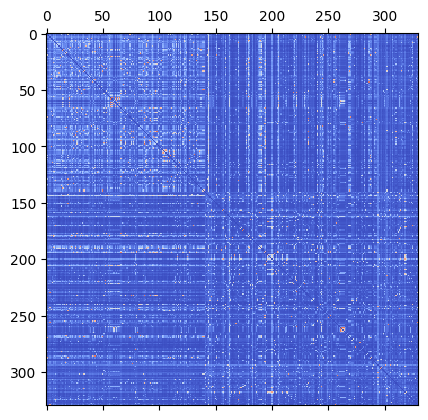

In [25]:
diSiNet = getDiSiNet(dilen=dilen, diseases=diseases, w=0.5)
plt.matshow(diSiNet, cmap= plt.cm.coolwarm, vmin=0, vmax=1)
# np.save('Fu/Fd', diSiNet)
np.save('dataset2/DSS', diSiNet)

In [26]:
print(diSiNet.shape) 

(330, 330)


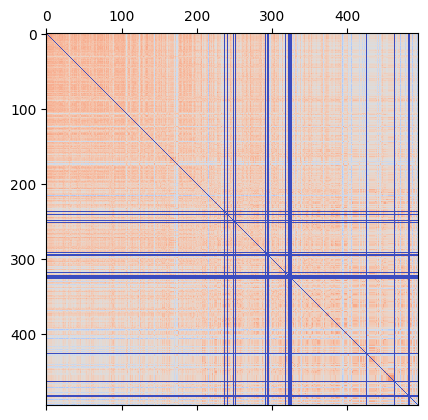

In [18]:
miSiNet = getRNASiNet(RNAlen=milen, diSiNet=copy.copy(diSiNet), rna_di=copy.copy(mi_di))
plt.matshow(miSiNet, cmap= plt.cm.coolwarm, vmin=0, vmax=1)
# np.save('Fu/Fm', miSiNet)


(711, 711)


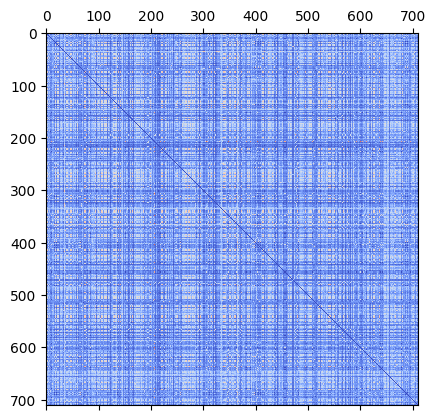

In [27]:
lncSiNet = getRNASiNet(RNAlen=lnclen, diSiNet=copy.copy(diSiNet), rna_di=copy.copy(lnc_di))
plt.matshow(lncSiNet, cmap= plt.cm.coolwarm, vmin=0, vmax=1)
# np.save('Fu/Fl', lncSiNet)
np.save('dataset2/LFS', lncSiNet)
print(lncSiNet.shape) 

In [19]:
part1 = np.vstack([lncSiNet[1], lnc_di[:, 3]])
part2 = np.vstack([lnc_di[1], diSiNet[3]])
part3 = np.vstack([lnc_mi[1], mi_di[:, 3]])

In [20]:
P2_4 = np.hstack([part1, part2, part3])

In [21]:
P2_4

array([[0.        , 0.        , 0.37393365, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
Pi_j = np.hstack([part1, part2, part3])

In [23]:
Pi_j_list = []

In [26]:
for i, j in positive_ij:
    part1 = np.vstack([lncSiNet[i], lnc_di[:, j]])
    part2 = np.vstack([lnc_di[i], diSiNet[j]])
    part3 = np.vstack([lnc_mi[i], mi_di[:, j]])
    Pi_j = np.hstack([part1, part2, part3])
    Pi_j_list.append(Pi_j)

In [27]:
stacked_Pi_j = np.stack(Pi_j_list, axis=-1)

In [37]:
stacked_Pi_j.shape

(2, 1147, 2697)

In [36]:
np.save('Fu/stacked_Pi_j.npy', stacked_Pi_j)

In [28]:
diSiNet[3].shape

(412,)

In [ ]:
lnclen=lnclen, dilen=dilen, milen=milen, lnc_di=lnc_di, lnc_mi=lnc_mi, mi_di=mi_di, lncSiNet=lncSiNet, diSiNet=diSiNet, miSiNet=miSiNet

# 五折交叉验证法

In [28]:
positive_ij, negative_ij = get_posi_nega_ij(lnclen=lnclen, dilen=dilen, lnc_di=lnc_di)
print(positive_ij.shape, negative_ij.shape)

(8101, 2) (226529, 2)


In [21]:
positive_ij[100]

array([12, 35])

In [22]:
negative_ij

array([[  0,   0],
       [  0,   1],
       [  0,   2],
       ...,
       [239, 409],
       [239, 410],
       [239, 411]])

In [29]:
# np.save('Fu/positive_ij.npy', positive_ij)
# np.save('Fu/negative_ij.npy', negative_ij)
np.save('dataset2/positive_ij.npy', positive_ij)
np.save('dataset2/negative_ij.npy', negative_ij)

In [30]:
folds(positive_ij.shape[0], negative_ij.shape[0], 'dataset') # Run only once

In [31]:
positive5foldsidx = np.load('dataset2/positive5foldsidx.npy', allow_pickle=True)
negative5foldsidx = np.load('dataset2/negative5foldsidx.npy', allow_pickle=True)

In [32]:
len(positive5foldsidx[0]['train'])

6480

In [31]:
positive5foldsidx

array([{'train': array([2650,  644, 1666, ..., 1837,  787,  208]), 'test': array([ 135,  306, 2371, 1480, 2050,  915, 2523, 2036, 1331,  223, 1946,
              1738,  939, 1544,  211, 1288, 1116, 1469,  810, 1266, 2390, 1496,
              2633, 2136,  278,  295,  400, 1115, 2002,  577, 2626,  807, 1993,
              1962, 1689,  130, 1855, 2391, 1281,  544, 2023, 2671,   61, 2496,
              1937, 2172,  200, 1511, 1663, 2689, 1107, 2427,  690,  781, 2416,
              1889, 1380,  559, 1886,  436,  379, 1505,   90, 1545, 1642, 2428,
              2236, 1001,  195, 1012, 1018, 1688,  233,  912, 2320, 1044, 1106,
               586,  496,  232, 1113,  663, 1308, 1438,  210, 1419, 2164,  177,
              2351, 1455,  978,  293,   19, 2003, 2129, 2166,   81, 2513, 1328,
               522, 1712, 1294, 1911,  159,  247, 2321,  904, 1045, 1526, 2263,
               756, 1846, 1634,  185, 1736,  651, 1037,  952, 1474, 1928, 2123,
               556, 1363,  343, 2333,  349, 2420, 11

(1147, 1147)


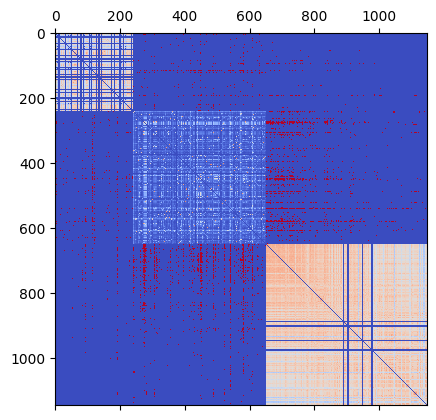

In [19]:
lncSiNet = getRNASiNet(RNAlen=lnclen, diSiNet=copy.copy(diSiNet), rna_di=copy.copy(lnc_di))

A = cancatenate(lnclen=lnclen, dilen=dilen, milen=milen, lnc_di=lnc_di, lnc_mi=lnc_mi, mi_di=mi_di, lncSiNet=lncSiNet, diSiNet=diSiNet, miSiNet=miSiNet)
plt.matshow(A, cmap= plt.cm.coolwarm, vmin=0, vmax=1)
# plt.savefig('Fu/fig/A.jpg', dpi=1200)
# np.save('Fu/A', A)
print(A.shape)

(1147, 1147)
(1147, 1147)
(1147, 1147)
(1147, 1147)
(1147, 1147)


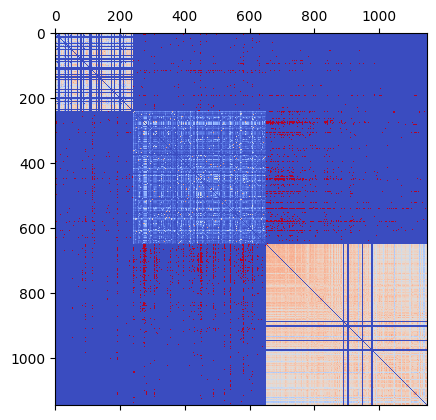

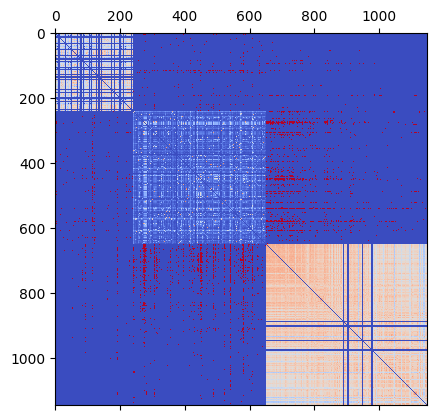

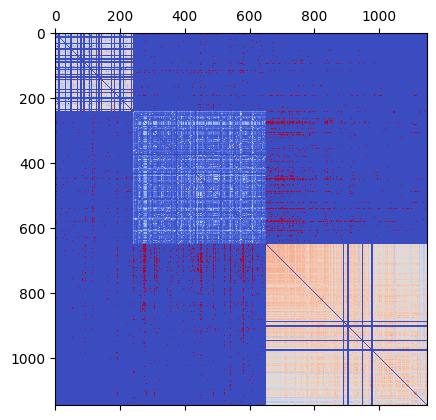

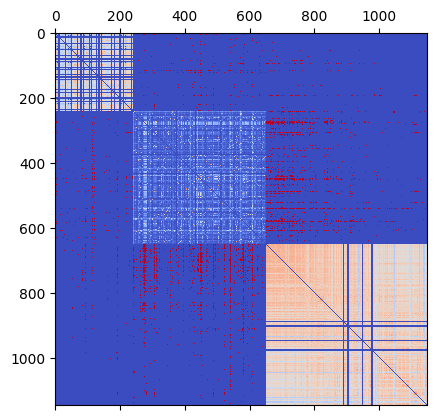

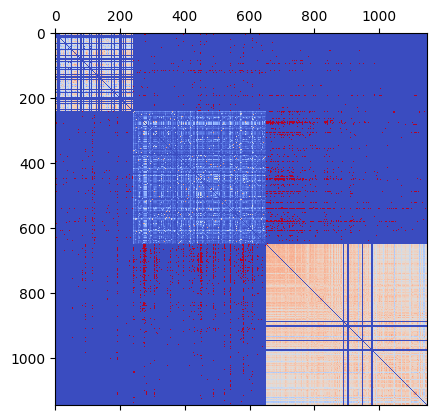

In [25]:
for fold in range(5):
    lnc_di_copy = copy.copy(lnc_di)
    for ij in positive_ij[positive5foldsidx[fold]['test']]:
        lnc_di_copy[ij[0], ij[1] - lnclen] = 0
    lncSiNet_copy = getRNASiNet(RNAlen=lnclen, diSiNet=copy.copy(diSiNet), rna_di=lnc_di_copy)
    A = cancatenate(lnclen=lnclen, dilen=dilen, milen=milen, lnc_di=lnc_di_copy, lnc_mi=lnc_mi, mi_di=mi_di, lncSiNet=lncSiNet_copy, diSiNet=diSiNet, miSiNet=miSiNet)
    plt.matshow(A, cmap= plt.cm.coolwarm, vmin=0, vmax=1)
    # plt.savefig('Fu/fig/A_' + str(fold) + '.jpg', dpi=1200)
    # np.save('Fu/A_' + str(fold), A)
    print(A.shape)